La prueba realizada ejecuta:



*   Librerias
*   Gaussian isotropic filter


*   Reconstruction algorithms
*   Atenuacion

- Resampling a 1 mm
- Funcion applicada a uno en especifico





#Librerias

In [ ]:

!pip install nilearn nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 97.2 MB/s eta 0:00:00


In [ ]:
import nibabel as nib
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.signal import butter, filtfilt
import os
import imageio
from tqdm import tqdm

import matplotlib.pyplot as plt

#from evaluate import get_diff_img
# import preprocessing as pp_utils # ----------------------

from pathlib import Path
from nilearn.image import resample_img

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


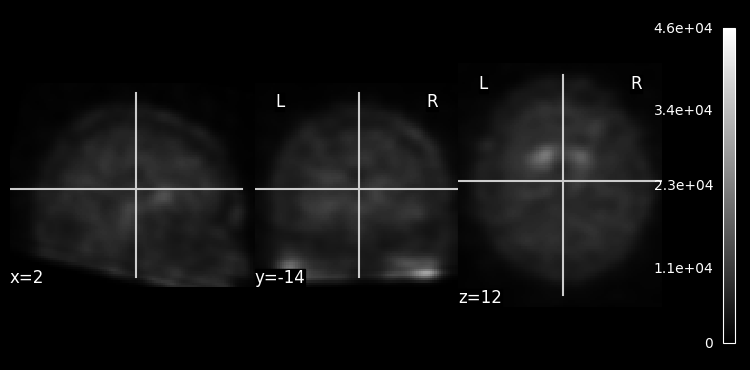

In [ ]:
from nilearn import plotting,image
ruta="/content/drive/MyDrive/Parkinson-Multimodal/paciente_3102/spect/PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893.nii"
plotting.plot_anat(ruta)


plotting.show()

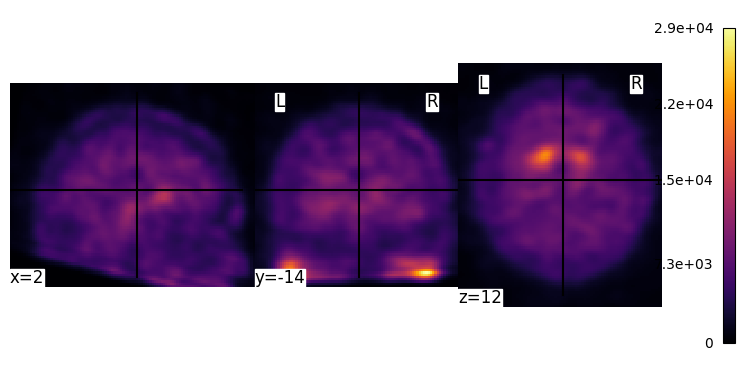

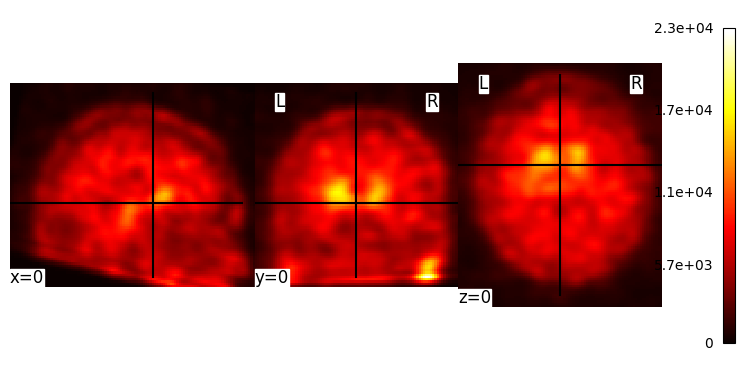

In [ ]:

img = image.load_img(ruta)
data = img.get_fdata()

# Calcular rango robusto (evita que valores extremos dañen el contraste)
vmin = np.percentile(data, 5)
vmax = np.percentile(data, 95)

# Visualización mejorada
plotting.plot_img(
    img,
    cmap="inferno",        # mejor que gris para SPECT
    # vmin=vmin,
    # vmax=vmax,
    display_mode="ortho",  # vistas axial, coronal, sagital
    cut_coords=(2, -14, 12),  # centro (puedes cambiarlo)
    colorbar=True
)

plotting.plot_img(
    img,
    cmap="hot",        # mejor que gris para SPECT
    # vmin=vmin,
    # vmax=vmax,
    display_mode="ortho",  # vistas axial, coronal, sagital
    cut_coords=(0, 0, 0),  # centro (puedes cambiarlo)
    colorbar=True
)

plotting.show()

X negativo → lado izquierdo

X positivo → lado derecho

Y negativo → parte trasera

Y positivo → parte frontal

Z negativo → parte baja

Z positivo → parte alta

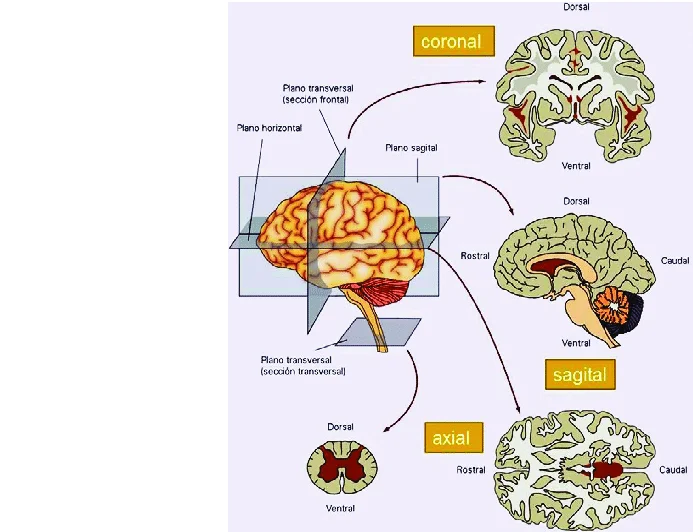

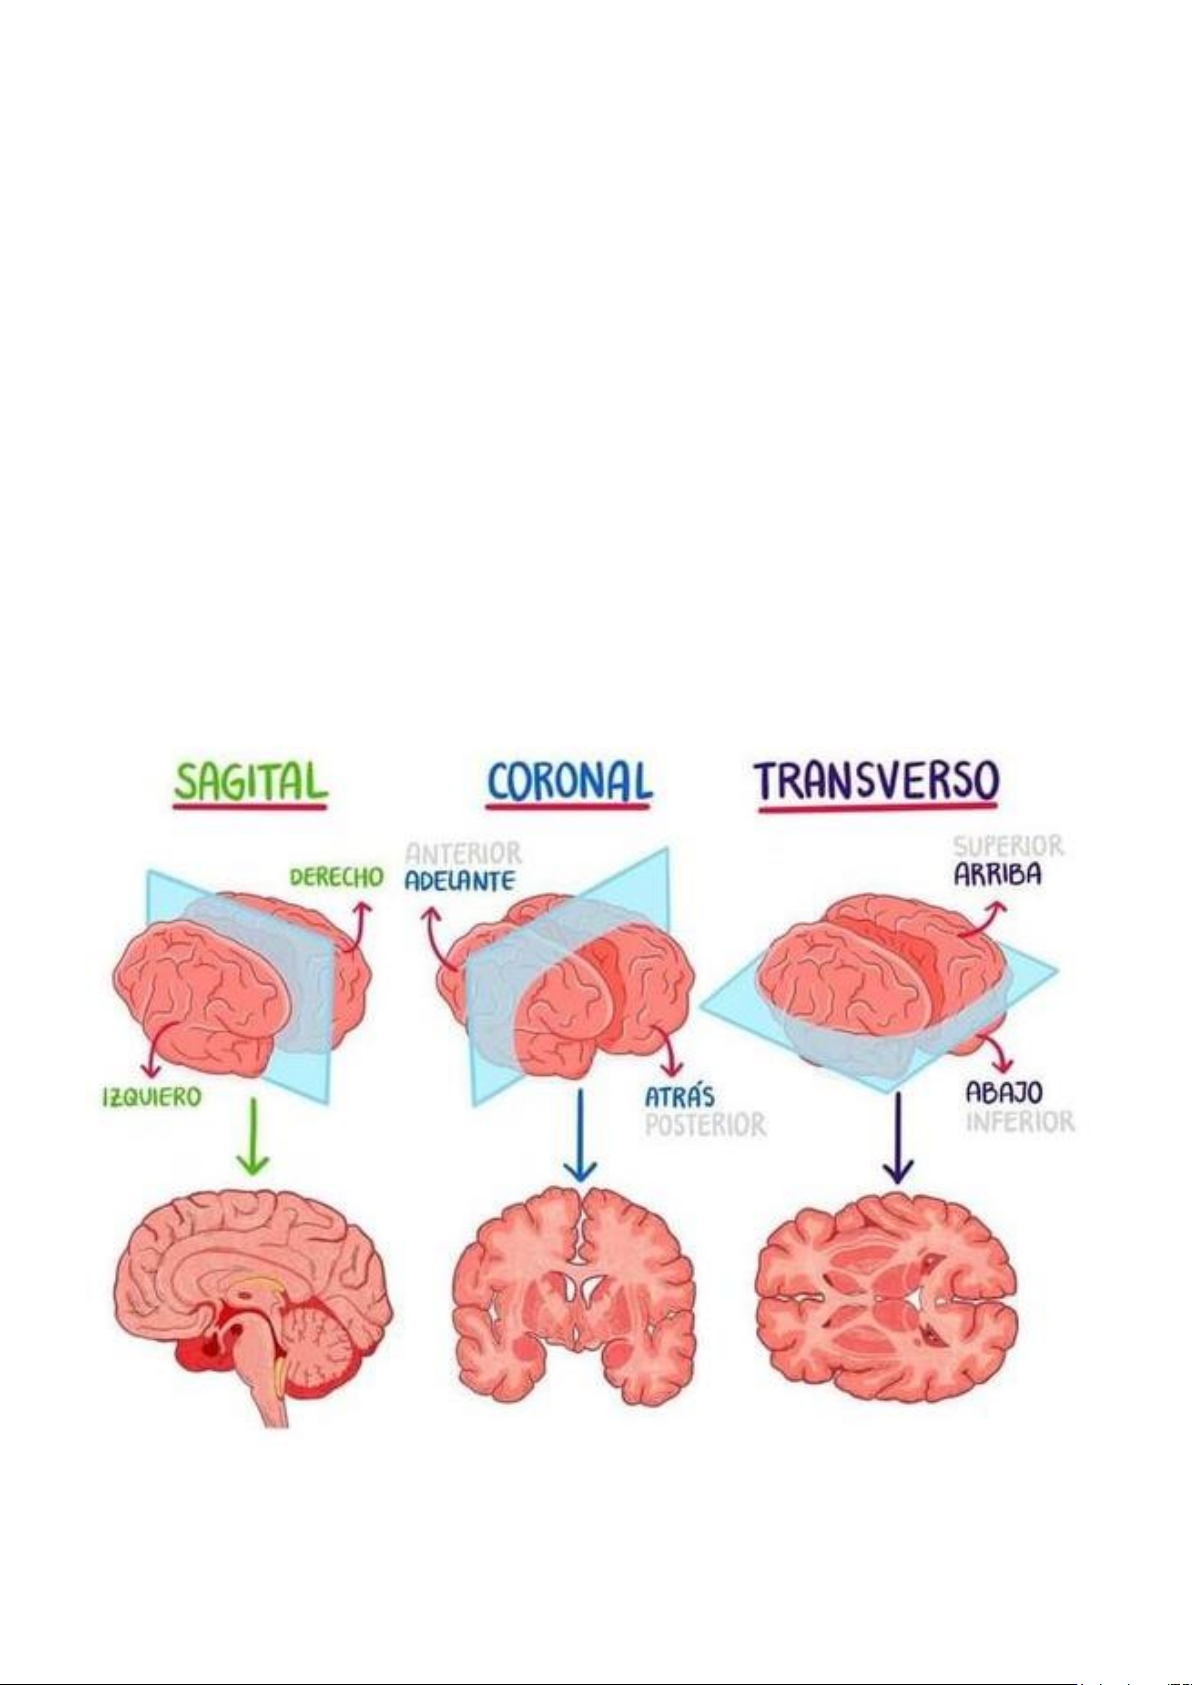

In [ ]:
import numpy as np
from nilearn import image

img = image.load_img(ruta)
data = img.get_fdata()
affine = img.affine

# Obtener dimensiones
shape = data.shape

# Coordenadas de los bordes (en vóxeles)
corners = np.array([
    [0, 0, 0],
    [shape[0], shape[1], shape[2]]
])

# Convertir a coordenadas reales (mm)
real_coords = np.dot(affine, np.vstack((corners.T, [1,1])))

print(real_coords)

[[  90.  -92.]
 [-126.   92.]
 [ -74.  108.]
 [   1.    1.]]


[ X1   X2 ]

[ Y1   Y2 ]

[ Z1   Z2 ]

[ 1    1  ]

#1. Gaussian isotropic filter

**Suavizado espacial ("desenfoque")**

Suavizado de texturas
Ej: Si tienes un píxel muy brillante (ruido) rodeado de píxeles oscuros, el suavizado "reparte" ese brillo entre los vecinos.

Resultado: El punto brillante se apaga un poco y los oscuros se aclaran un poco.

Reducir el Ruido para Resaltar la Estructura. Intencidad constante.





In [ ]:
def apply_gaussian_filter(input_file, output_dir):
    fwhm_mm = 18
    # Load the NIfTI file-cargar el archivo
    img = nib.load(input_file)
    data = img.get_fdata()

    # Get voxel dimensions-dimensiones voxel
    voxel_sizes = img.header.get_zooms()
    #print("voxel_sizes: ", voxel_sizes)

    # Convert FWHM from mm to voxel units-convierta (FWHM) de milímetros a unidades de vóxel.
    fwhm_voxel = fwhm_mm / np.array(voxel_sizes)

    # Apply Gaussian filter - filtro gaussiano
    filtered_data = gaussian_filter(data, sigma=fwhm_voxel / (2*np.sqrt(2*np.log(2))))

    # Save the filtered data to a new NIfTI file -  nuevo archivo
    filtered_img = nib.Nifti1Image(filtered_data, img.affine, img.header)

    # check if the output dir exists - existe el directorio de salida?

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    sufix = "_gaussian.nii.gz"
    original_name = input_file.split("/")[-1]
    current_original_name = original_name.split(".")[0]
    #current_original_name = original_name.split(".")[-3]#se rige en lo que hay despues de los 2 puntos
    prefixed_name = f"{current_original_name}{sufix}"
    output_file = output_dir + "/" + prefixed_name
    print("output_file: ", output_file)
    nib.save(filtered_img, output_file)

    return output_file

Detalles:


*   FWHM (Full Width at Half Maximum: medida que define qué tan "ancho" es el desenfoque), en este caso de 18 mm.


- Ajuste por Tamaño de Vóxel:  
  Se observa el tamaño de cada voxel. Convierte el suavizado de milímetros a unidades de vóxel. Esto asegura que el desenfoque sea uniforme en el espacio físico, sin importar si los vóxeles son rectangulares o cúbicos.

 - Aplicación del Filtro Gaussiano:  
Cada punto de la imagen se promedia con sus vecinos siguiendo una campana de Gauss, lo que resulta en una imagen más "borrosa" pero con menos ruido de alta frecuencia

El objetivo de apply_gaussian_filter no es solo "borrar" la imagen, sino preparar los datos para que el análisis científico sea más robusto. Sus tres metas principales son:

Aumentar la Relación Señal-Ruido (SNR): El ruido en las imágenes médicas suele ser aleatorio y de alta frecuencia (puntos sueltos). Al promediar los vóxeles, el ruido tiende a cancelarse, mientras que la señal real (que suele ocupar varios vóxeles adyacentes) se mantiene y resalta.

Compensar la variabilidad anatómica: Si estás comparando los cerebros de 10 personas, sus giros y surcos no coinciden perfectamente. El suavizado "borra" esas pequeñas diferencias anatómicas para que, al superponer los cerebros, las áreas funcionales (como la corteza motora) coincidan mejor.

Cumplir con la Teoría de Campos Aleatorios: Muchos análisis estadísticos posteriores asumen que los datos tienen una distribución espacial continua y normal. El filtro Gaussiano garantiza que los datos cumplan con estos requisitos matemáticos para que los resultados sean válidos.

En resumen: El objetivo es sacrificar un poco de detalle espacial (resolución) para ganar mucha más confianza estadística y capacidad de comparar diferentes sujetos entre sí.

Pregunta?
Por que 18 mm, no tiene implicaciones en la parte de que se  dispersará tanto que se perdera la forma característica de la imagen

In [ ]:
#Aplicacion para imagenes 2D(slices)
def apply_gaussian_filter_pngs(image_path, output_path, sigma):
    # Read the image
    #Transformacion de la imagen a pixeles
    image = imageio.imread(image_path)

    # Apply the Gaussian filter
    #sigma radio de influencia en píxeles vecinos
    filtered_image = gaussian_filter(image, sigma=sigma)

    # Save the filtered image
    imageio.imwrite(output_path, filtered_image)

#2. Reconstruction algorithms

a) Filtro Butterworth de quinto orden con una frecuencia de corte de 0,6 ciclos/píxel.

In [ ]:
def butterworth_filter(input_file, output_dir, order=5, cutoff=0.1):
    # Load the NIfTI file
    img = nib.load(input_file)
    data = img.get_fdata() #niveles de intensidad

    # Get voxel dimensions - mm
    voxel_sizes = img.header.get_zooms()[:3]  # Extract voxel dimensions

    # Calculate sampling rate based on voxel dimensions
    sampling_rate = 1 / min(voxel_sizes)

    # Calculate Nyquist frequency
    nyquist_freq = 0.5 * sampling_rate  # Nyquist frequency

    #print("Nyquist Frequency:", nyquist_freq)  # Debugging statement

    # Normalize cutoff frequency
    normalized_cutoff = cutoff / nyquist_freq #filtro se comporte igual aunque se cambie la resolución del SPECT
    #print("Normalized Cutoff Frequency:", normalized_cutoff)  # Debugging statement

    # Check if normalized cutoff is within valid range
    if normalized_cutoff >= 1:
        raise ValueError("Cutoff frequency exceeds Nyquist frequency.")

    # Design Butterworth filter
    b, a = butter(order, normalized_cutoff, btype='low', analog=False)

    # Apply filter to each slice of the data
    filtered_data = np.zeros_like(data)
    for i in range(data.shape[-1]):
        filtered_data[..., i] = filtfilt(b, a, data[..., i], axis=0)

    # check if the output dir exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    sufix = "_butterworth.nii.gz"
    original_name = input_file.split("/")[-1]
    current_original_name = original_name.split(".")[0]
    #current_original_name = original_name.split(".")[-3]
    prefixed_name = f"{current_original_name}{sufix}"
    output_file = output_dir + "/" + prefixed_name


    # Save the filtered data back to a nii file
    filtered_nii = nib.Nifti1Image(filtered_data, affine=img.affine)
    nib.save(filtered_nii, output_file)

    return output_file

Aunque ambos sirven para "suavizar", con respecto al filtro gaussiano, el filtro de Butterworth es mucho más técnico y preciso: es un filtro de procesamiento de señales que busca eliminar el ruido de alta frecuencia de forma más tajante.

En el contexto de tu SPECT de Parkinson, mientras que el Gaussiano es como usar una brocha gorda para difuminar, el Butterworth es como usar un escalpelo digital.

El objetivo final de esta función es limpiar la imagen SPECT de forma quirúrgica.

En Parkinson, el ruido puede hacer que el centro del estriado parezca tener "huecos" que no existen. El filtro de Butterworth:

Rellena esos huecos artificiales causados por el ruido estadístico de la máquina.

Mantiene la forma de la "coma" de manera más fiel que el filtro Gaussiano de 18 mm (que era demasiado exagerado).

Prepara la imagen para cuantificación: Al dejar la imagen más limpia, es más fácil para un software medir exactamente cuántos fotones hay en el área de interés.

En resumen: Si el Gaussiano es para que la imagen se vea "bien", el Butterworth es para que la imagen sea matemáticamente óptima para un análisis posterior.

Paso a paso de la función Butterworth:
Carga del volumen (NIfTI): Utiliza la librería nibabel para leer el archivo .nii.gz y extrae la matriz de datos (fdata), que contiene los niveles de intensidad del radiotrazador en el cerebro.

Análisis del Vóxel: Obtiene las dimensiones físicas (en mm) de los vóxeles. Esto es vital porque el ruido en un SPECT depende de qué tan pequeña es la "rejilla" de captura.

Cálculo de la Tasa de Muestreo y Nyquist: Determina la "resolución máxima" permitida. La Frecuencia de Nyquist es el límite físico: no puedes filtrar frecuencias más altas de las que la máquina pudo grabar.

Normalización del Corte (Cutoff): Ajusta el valor de cutoff=0.1 para que sea relativo a la escala de tu imagen. Esto asegura que el filtro se comporte igual aunque cambies la resolución del SPECT.

Diseño del Filtro (Orden 5): Se crea la "curva de respuesta" del filtro de Butterworth. Al ser de orden 5, la caída de la curva es muy pronunciada, lo que significa que elimina el ruido de forma muy eficiente sin afectar las frecuencias bajas (la señal real).

Procesamiento por Rebanadas (Slices): La función recorre el volumen eje por eje y aplica filtfilt. Este comando es clave: filtra la imagen, la voltea y la vuelve a filtrar. Esto cancela cualquier desplazamiento de fase, manteniendo el núcleo estriado exactamente en su posición anatómica original.

Reconstrucción y Guardado: Empaqueta los datos limpios de nuevo con la cabecera original (para no perder la orientación espacial) y guarda el archivo con el sufijo _butterworth.

CONCLUSION: Ambos filtros buscan lo mismo: eliminar el ruido de alta frecuencia (suavizar).

Si aplicas un Gaussiano (18 mm) y luego un Butterworth, estarás "borrando" la imagen dos veces. El resultado será un cerebro tan difuso que no podrás distinguir el putamen del caudado, lo cual es fatal para un diagnóstico de Parkinson.

#3. Atenuacion


b) Corrección de atenuación uniforme posterior a la reconstrucción según Chang (mu=0,12/cm), sin corrección de dispersión.

In [ ]:
def apply_attenuation_correction(input_file, output_dir, attenuation_coefficient=0.12):
    # Load the SPECT NIfTI file
    img = nib.load(input_file)
    # Extract image data from the NIfTI file
    spect_data = img.get_fdata()


    # Apply attenuation correction using Chang's method
    corrected_data = spect_data * np.exp(-attenuation_coefficient)

    # check if the output dir exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    sufix = "_attenuated.nii.gz"
    original_name = input_file.split("/")[-1]
    current_original_name = original_name.split(".")[0]
    #current_original_name = original_name.split(".")[-3]
    prefixed_name = f"{current_original_name}{sufix}"
    output_file = output_dir + "/" + prefixed_name
    # Save the filtered data back to a nii file
    filtered_nii = nib.Nifti1Image(corrected_data, affine=img.affine)
    nib.save(filtered_nii, output_file)

    return output_file

 Tu función está aplicando un factor de corrección uniforme a toda la imagen. Multiplica cada píxel por el mismo número ($e^{-0.12} \approx 0.88$). En la práctica, esto baja el brillo de toda la imagen por igual en lugar de corregir las diferencias de profundidad.

#Resampling a 1mm

In [ ]:
def resampling(root_path, adc_path=None, results_dir=None, ncct_path=None):

    results_dir.mkdir(exist_ok=True)

    '''def resample_to_isotropic(nib_image, target_voxel_size=(1.0, 1.0, 1.0), interpolation='linear'):
        """
        Resamplea una imagen NIfTI a resolución isotrópica 1mm³ usando nilearn.
        """
        target_affine = np.diag(list(target_voxel_size) + [1])
        resampled = resample_img(
            nib_image,
            target_affine=target_affine,
            interpolation=interpolation
        )
        return resampled.get_fdata(), resampled.affine, resampled.header'''

    ######################################################################################################
    def resample_to_isotropic(nib_image, target_voxel_size=(1.0, 1.0, 1.0), interpolation='linear'):
        """
        Resamplea una imagen NIfTI a resolución isotrópica 1mm³ usando nilearn.
        """
        # Conservar la orientación original, solo cambiar el tamaño del voxel
        affine = nib_image.affine
        target_affine = np.copy(affine)

        # Escalar cada columna del affine al tamaño de voxel deseado
        for i in range(3):
            col_norm = np.linalg.norm(affine[:3, i])
            target_affine[:3, i] = affine[:3, i] / col_norm * target_voxel_size[i]

        resampled = resample_img(
            nib_image,
            target_affine=target_affine,
            interpolation=interpolation
        )
        return resampled.get_fdata(), resampled.affine, resampled.header
    ######################################################################################################

    if adc_path is not None:
        # Detecta la extensión (.nii o .nii.gz)
        adc_extension = "".join(adc_path.suffixes)
        print("adc_extension:", adc_extension)
        adc_filename = adc_path.name.replace(adc_extension, "")
        print("adc_filename:", adc_filename)

        # Carga la imagen cruda
        adc = nib.load(adc_path)
        print("file loaded")

        # Aplica el resampling
        '''arr - voxeles | aff - ubicacion de cada voxel | header - metadata'''
        adc_arr, adc_aff, adc_header = resample_to_isotropic(adc, target_voxel_size=(1.0, 1.0, 1.0), interpolation='linear')
        print("resampled")

        # Crea nueva imagen con los datos resampled
        adc_resampled_img = nib.Nifti1Image(adc_arr, adc_aff, adc_header)
        adc_resampled_path = results_dir / f"{adc_filename}_resampled{adc_extension}"

        # Guarda con nombre *_resampled.nii
        nib.save(adc_resampled_img, adc_resampled_path)
        print(f"saved: {adc_resampled_path}")
    else:
        adc_resampled_path = None

    if ncct_path is not None:
        ncct_extension = "".join(ncct_path.suffixes)
        ncct_filename = ncct_path.name.replace(ncct_extension, "")

        ncct = nib.load(ncct_path)
        print("NCCT file loaded")

        ncct_arr, ncct_aff, ncct_header = resample_to_isotropic(ncct, target_voxel_size=(1.0, 1.0, 1.0), interpolation='linear')
        print("resampled")

        ncct_resampled_img = nib.Nifti1Image(ncct_arr, ncct_aff, ncct_header)
        ncct_resampled_path = results_dir / f"{ncct_filename}_resampled{ncct_extension}"
        nib.save(ncct_resampled_img, ncct_resampled_path)
        print(f"saved: {ncct_resampled_path}")
    else:
        ncct_resampled_path = None

    if adc_path is None and ncct_path is None:
        print("No ADC or NCCT path was given")
        return None, None, None
    elif adc_path is None:
        return None, ncct_resampled_path
    elif ncct_path is None:
        return adc_resampled_path, None

    return adc_resampled_path, ncct_resampled_path

In [ ]:
from pathlib import Path

# Configura tus rutas de Drive
drive_path = Path("/content/drive/MyDrive/Parkinson-Multimodal/paciente_3102/spect")
archivo_original = drive_path / "PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893.nii" # Pon el nombre real aquí
intento_internet=drive_path/""
carpeta_resultados = drive_path / "resampled_data"

# Llamar a la función (usamos adc_path porque el código lo pide así, pero es tu SPECT)
ruta_resampled, _ = resampling(
    root_path=drive_path,
    adc_path=archivo_original, # Pasamos tu SPECT aquí
    results_dir=carpeta_resultados
)

print(f"El nuevo archivo está en: {ruta_resampled}")

adc_extension: .nii
adc_filename: PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893
file loaded
resampled
saved: /content/drive/MyDrive/Parkinson-Multimodal/paciente_3102/spect/resampled_data/PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893_resampled.nii
El nuevo archivo está en: /content/drive/MyDrive/Parkinson-Multimodal/paciente_3102/spect/resampled_data/PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893_resampled.nii


#Funciones aplicadas en todos los pacientes

Obtener los datos a utilizar.

Previamente se debio realizar el resampled de las imagenes.

In [ ]:
#getting all the related cases
root_path = "/home/Data/Datasets/Parkinson/radiological/PPMI/spect-mri/filtered/FinalExtension/data/classifier"
split = "train"
group = "parkinson"
modality = "spect"
current_path = root_path + "/" + group + "_" + split + "/" + modality + "_png"
cases = sorted(os.listdir(current_path))
print(len(cases))



FileNotFoundError: [Errno 2] No such file or directory: '/home/Data/Datasets/Parkinson/radiological/PPMI/spect-mri/filtered/FinalExtension/data/classifier/parkinson_train/spect_png'

APLICACION DEL SUAVIZADO Y ATENUACION

In [ ]:
for case in cases:
    print(case)
    preprocessed_case_path = current_path + "/" + case + "/" + "preprocessed"
    output_dir = current_path + "/" + case + "/" + "preprocessed2"
    files = os.listdir(preprocessed_case_path)
    nii_file = [file for file in files if file.endswith("_resampled.nii.gz")][0]

    #step 1 to preprocess (apply gaussian filter)
    nii_file_path = preprocessed_case_path + "/" + nii_file
    input_file = nii_file_path
    output_file = apply_gaussian_filter(input_file, output_dir)

    #step 2 to preprocess (apply Butterworth reconstruction filter)
    output_file = butterworth_filter(input_file=output_file, output_dir=output_dir, order=5, cutoff=0.1)

    #step 3 to preprocess (attenuation correction)
    corrected_data = apply_attenuation_correction(output_file, output_dir, attenuation_coefficient=0.12) # Assuming linear attenuation coefficient of 0.12/cm

print("done!")


NameError: name 'cases' is not defined

#Funciones aplicadas a uno en especifico

Previamente se debio realizar el resampled de las imagenes.

In [ ]:

current_path = "/content/drive/MyDrive/Parkinson-Multimodal/paciente_3102/spect/resampled_data"

# Listamos los archivos en esa carpeta
files = os.listdir(current_path)

# Buscamos el archivo
nii_file = [file for file in files if file.endswith("_resampled.nii") or file.endswith("_resampled.nii.gz")][0]

nii_file_path = os.path.join(current_path, nii_file)
input_file = nii_file_path

# 3. Definimos dónde se guardará el resultado (creando una subcarpeta nueva)
output_dir = os.path.join(current_path, "filtros")

# Creamos la carpeta si no existe para evitar errores
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Leyendo desde: {input_file}")
print(f"Guardando en: {output_dir}")

# --- Iniciamos el Pipeline ---

# Paso 1: Filtro Gaussiano
output_file = apply_gaussian_filter(input_file, output_dir)

# Paso 2: Filtro Butterworth (usamos el output del paso anterior)
output_file = butterworth_filter(input_file=output_file, output_dir=output_dir, order=5, cutoff=0.1)

# Paso 3: Corrección de Atenuación
corrected_data = apply_attenuation_correction(output_file, output_dir, attenuation_coefficient=0.12)

Leyendo desde: /content/drive/MyDrive/Parkinson-Multimodal/paciente_3102/spect/resampled_data/PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893_resampled.nii
Guardando en: /content/drive/MyDrive/Parkinson-Multimodal/paciente_3102/spect/resampled_data/filtros
output_file:  /content/drive/MyDrive/Parkinson-Multimodal/paciente_3102/spect/resampled_data/filtros/PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893_resampled_gaussian.nii.gz


#Para slices

Carpeta nueva con una colección de imágenes perfectamente limpias y estandarizadas- slices (png).

Todas las imágenes del grupo de control habrán pasado por el mismo proceso:

Solo tienes las rebanadas donde se ve el área del Parkinson.

Todas tienen el mismo nivel de suavizado (el sigma que calculaste).

Ya no tienen el "grano" o ruido del SPECT original.

In [ ]:
# Example usage
# Define the FWHM and calculate sigma
FWHM = 18  # in mm
sigma = FWHM / 2.3548
root_path = "/home/Data/franklin/Doctorado/parkinson/projects/T1-SPECT-PD-translation/imgs_results/t12spect/"
split = "train"
group = "control"
cases = sorted(os.listdir(root_path + split + "/" + group + "/"))
print("total of cases: ", len(cases))

for case in tqdm(cases):
    print("case: ", case)
    case_path = root_path + split + "/" + group + "/" + case + "/"
    images = sorted(os.listdir(case_path))
    for image in images:
        general_inf = image.split(".")[0]
        img_num = int(general_inf.split("_")[-1])
        if img_num >= 57 and img_num <= 66:
            input_image_path = case_path + image
            directory = root_path + "preprocessed/" + split + "/" + group + "/" + case

            if not os.path.exists(directory):
                os.makedirs(directory)
            else:
                None

            output_image_path = directory + "/" + image
            # print("input_image_path: ", input_image_path)
            # print("output_image_path: ", output_image_path)
            apply_gaussian_filter_pngs(input_image_path, output_image_path, sigma)
        else:
            None

#EXPERIMENTO

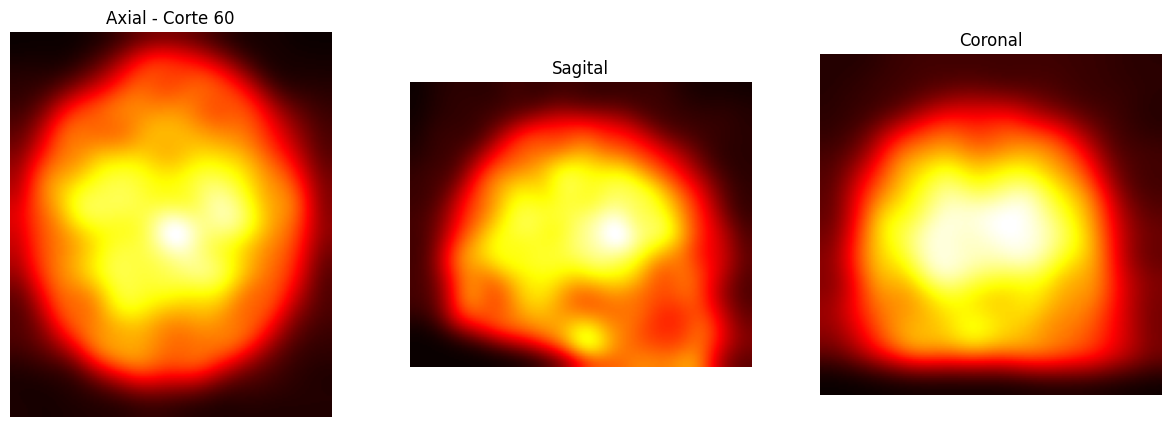

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar la imagen final (la que salió de la atenuación)
img_obj = nib.load("/content/drive/MyDrive/Parkinson-Multimodal/paciente_3102/spect/resampled_data/filtros/PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893_resampled_gaussian_butterworth_attenuated.nii.gz") # 'corrected_data' es la ruta de tu último filtro
data = img_obj.get_fdata()

# 2. Elegir un corte central (por ejemplo, el 60 que es donde se ve el estriado)
slice_idx = 60

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Corte Axial (Desde arriba)
axes[0].imshow(np.rot90(data[:, :, slice_idx]), cmap='hot')
axes[0].set_title(f'Axial - Corte {slice_idx}')
axes[0].axis('off')

# Corte Sagital (De lado)
axes[1].imshow(np.rot90(data[slice_idx, :, :]), cmap='hot')
axes[1].set_title('Sagital')
axes[1].axis('off')

# Corte Coronal (De frente)
axes[2].imshow(np.rot90(data[:, slice_idx, :]), cmap='hot')
axes[2].set_title('Coronal')
axes[2].axis('off')

plt.show()

In [ ]:
from ipywidgets import interact, IntSlider

def explorar_cerebro(z):
    plt.figure(figsize=(6, 6))
    # Usamos 'hot' o 'magma' porque son los mejores para SPECT de Parkinson
    plt.imshow(np.rot90(data[:, :, z]), cmap='hot')
    plt.title(f"Paciente 3102 - Corte Axial: {z}")
    plt.axis('off')
    plt.show()

# Crear el control interactivo
interact(explorar_cerebro, z=IntSlider(min=0, max=data.shape[2]-1, step=1, value=60));

interactive(children=(IntSlider(value=60, description='z', max=180), Output()), _dom_classes=('widget-interact…

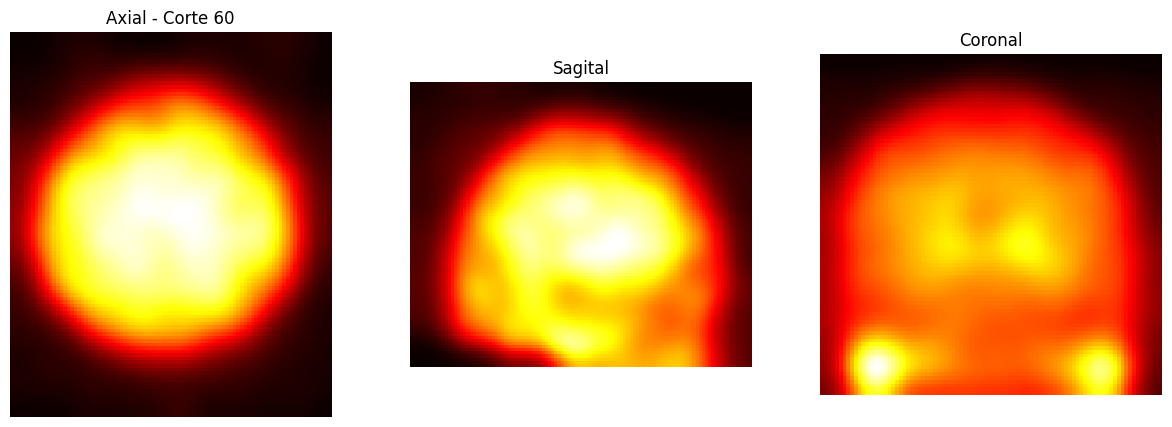

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar la imagen final (la que salió de la atenuación)
img_obj = nib.load("/content/drive/MyDrive/Parkinson-Multimodal/preprocesamiento_imagenes/PPMI_3~1.NII") # 'corrected_data' es la ruta de tu último filtro
data = img_obj.get_fdata()

# 2. Elegir un corte central (por ejemplo, el 60 que es donde se ve el estriado)
slice_idx = 60

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Corte Axial (Desde arriba)
axes[0].imshow(np.rot90(data[:, :, slice_idx]), cmap='hot')
axes[0].set_title(f'Axial - Corte {slice_idx}')
axes[0].axis('off')

# Corte Sagital (De lado)
axes[1].imshow(np.rot90(data[slice_idx, :, :]), cmap='hot')
axes[1].set_title('Sagital')
axes[1].axis('off')

# Corte Coronal (De frente)
axes[2].imshow(np.rot90(data[:, slice_idx, :]), cmap='hot')
axes[2].set_title('Coronal')
axes[2].axis('off')

plt.show()